# Exercise 4

## Import packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR

## Task 1
(3 points)

Implement the training loop for one training epoch.
An epoch trains on the whole training dataset once.

In [2]:
def train(model, use_cuda, train_loader, optimizer, epoch, log_interval):
    """
    Train one epoch
    
    model -- the neural network
    use_cuda -- true if GPU should be used
    train_loader -- data loader
    optimizer -- network optimizer
    epoch -- number of current epoch
    log_interval -- number of training steps between logs
    """
    # TODO: set the model to train mode
    model.train()
    
    
    # TODO: enumerate over the dataloader to get mini batches
    #       of images and ground truth labels
    # HINT: the builtin python function enumerate() also gives you indices
    for batch_idx, (data, target) in enumerate(train_loader):
        
        if use_cuda:
            data, target = data.cuda(), target.cuda()
        
        # TODO: set the optimizers gradients to zero
        optimizer.zero_grad()
        
        # TODO: run the network
        output = model(data)
        
        # TODO: compute negative log likelihood loss
        loss = F.nll_loss(output, target)
        
        
        # TODO: do backpropagation
        loss.backward()
        
        # TODO: optimize
        optimizer.step()
        
        # TODO: print current loss for every nth ("log_interval"th) iteration
        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))

We already implemented the validation function for you (this is essentially validate() from the last exercise)

In [3]:
def validate(model, use_cuda, test_loader):
    """
    Compute test metrics
    
    model -- the neural network
    use_cuda -- true if GPU should be used
    test_loader -- data loader
    """
    # create a 10x10 grid of subplots
    _, axis = plt.subplots(10, 10)
    
    # set model to evaluation mode
    model.eval()
    test_loss = 0
    correct = 0
    plotted = 0
    
    # disable gradients globally
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(test_loader):
            # for each batch
            if use_cuda:
                # transfer to GPU
                data = data.cuda()
                target = target.cuda()
            
            # run network and compute metrics
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            
            img_correct = pred.eq(target.view_as(pred))
            correct += pred.eq(target.view_as(pred)).sum().item()
            
            # plot the first 100 images
            img_idx = 0
            data = data.cpu().numpy()
            
            while plotted < 100 and img_idx < data.shape[0]:
                # compute position of ith image in the grid
                y = plotted % 10
                x = plotted // 10
                
                # convert image tensor to numpy array and normalize to [0, 1]
                img = data[img_idx, 0]
                img = (img - np.min(img)) / (np.max(img) - np.min(img))
                
                # make wrongly predicted images red
                img = np.stack([img] * 3, 2)
                if img_correct[img_idx] == 0:
                    img[:, :, 1:] = 0.0
                
                # disable axis and show image
                axis[y][x].axis('off')
                axis[y][x].imshow(img)
                
                # show the predicted class next to each image
                axis[y][x].text(30, 25, pred[img_idx].item())
                
                plotted += 1
                img_idx += 1
            
    test_loss /= len(test_loader.dataset)

    # show results
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))
    plt.show()

## Task 2
(4 points)

Implement a five-layer fully connected neural network.
The dimensions (without batch size) should change like this: 784->200->100->60->30->10
Use log softmax to compute the class predictions.

Run the code at the end of the notebook to train and validate your implementation.

### Task 2.1
* sigmoid non-linear activation function
* note that the last layer does not need an activation function!

### Task 2.2
* add a new class "FCNet2"
* replace sigmoid with ReLU

### Task 2.3
* add a new class "FCNet2"
* add batch normalization to the first and third layers (note the difference between 1D/2D/3D versions)


**NOTE:** The perfomance should improve slightly with each step. However, due to the random weight initialization applied by PyTorch, your results may vary a bit between trainings.

In [4]:
class FCNet1(nn.Module):
    """
    Fully Connected Neural Network
    
    Five fully connected layers with sigmoid non-linearity
    
    Dimensions
    784->200->100->60->30->10
    """
    def __init__(self):
        super(FCNet1, self).__init__()
        
        # TODO: initialize network layers
        # HINT: take a look at "torch.nn" (imported as "nn")
        self.fc1 = nn.Linear(784, 200)
        self.fc2 = nn.Linear(200, 100)
        self.fc3 = nn.Linear(100, 60)
        self.fc4 = nn.Linear(60, 30)
        self.fc5 = nn.Linear(30, 10)
       

    def forward(self, x):
        # TODO: reshape batch of images to batch of 1D vectors
        x = x.view(x.size(0), -1)
        
        
        # TODO: run network layers
        x = F.sigmoid(self.fc1(x))
        x = F.sigmoid(self.fc2(x))
        x = F.sigmoid(self.fc3(x))
        x = F.sigmoid(self.fc4(x))
        output = self.fc5(x)
        
        
        # TODO: compute log softmax over the output
        # HINT: take a look at "torch.nn.functional" (imported as "F")
        output = F.log_softmax(output, dim=1)
        
        
        return output

In [5]:
class FCNet2(nn.Module):
    def __init__(self):
        super(FCNet2, self).__init__()
        self.fc1 = nn.Linear(784, 200)
        self.fc2 = nn.Linear(200, 100)
        self.fc3 = nn.Linear(100, 60)
        self.fc4 = nn.Linear(60, 30)
        self.fc5 = nn.Linear(30, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        output = self.fc5(x)
        output = F.log_softmax(output, dim=1)
        return output

In [6]:
class FCNet3(nn.Module):
    def __init__(self):
        super(FCNet3, self).__init__()
        self.fc1 = nn.Linear(784, 200)
        self.fc2 = nn.Linear(200, 100)
        self.fc3 = nn.Linear(100, 60)
        self.fc4 = nn.Linear(60, 30)
        self.fc5 = nn.Linear(30, 10)
        self.bn1 = nn.BatchNorm1d(200)
        self.bn3 = nn.BatchNorm1d(60)
        
    def forward(self, x):        
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.bn1(x)
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.bn3(x)
        x = F.relu(self.fc4(x))
        output = self.fc5(x)
        output = F.log_softmax(output, dim=1)
        return output

## Task 3
(3 points)

Implement a convolutional neural network, consisting of two convolutional and two fully connected layers.
This time, the dimensions (without batch size) should change like this: 1x28x28->32x26x26->64x12x12->128->10

### Task 3.1
* two convolutional layers (kernel size 3)
* two fully-connected layers
* ReLU activation function

### Task 3.2
* add batch normalization to first convolutional and first fully connected layer

### Task 3.3
* use max pooling instead of stride to reduce the dimensions to 64x12x12

In [7]:
class ConvNet1(nn.Module):
    """
    Convolutional Neural Network
    
    Two convolutional layers and two fully connected layers
    
    Dimensions:
    1x28x28->32x26x26->64x12x12->128->10
    """
    def __init__(self):
        super(ConvNet1, self).__init__()
        
        # TODO: initialize network layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2)
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.fc2 = nn.Linear(128, 10)
        

    def forward(self, x):
        # TODO: run convolutional layers
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        
        
        # TODO: reshape batch of images to batch of 1D vectors
        x = torch.flatten(x, 1)
        
        
        # TODO: run fully connected layers
        x = F.relu(self.fc1(x))
        output = self.fc2(x)
        
        # TODO: compute log softmax over the output
        output = F.log_softmax(output, dim=1)
        
        
        return output

In [8]:
class ConvNet2(nn.Module):
    def __init__(self):
        super(ConvNet2, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2)
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 10)
        

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.bn1(x)
        x = F.relu(self.conv2(x))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.bn2(x)
        output = self.fc2(x)
        output = F.log_softmax(output, dim=1)
        
        
        return output

In [9]:
class ConvNet3(nn.Module):
    def __init__(self):
        super(ConvNet3, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        # x = F.max_pool2d(x, 2)
        x = self.bn1(x)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.bn2(x)
        output = self.fc2(x)
        output = F.log_softmax(output, dim=1)
        
        
        return output

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ../data/MNIST/raw/train-images-idx3-ubyte.gz to ../data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ../data/MNIST/raw/train-labels-idx1-ubyte.gz to ../data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ../data/MNIST/raw/t10k-images-idx3-ubyte.gz to ../data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ../data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ../data/MNIST/raw

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.325840
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.340665
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.349118
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.219381
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.229810
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.212302
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.093002
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.074782
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.258614
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.109870

Test set: Average loss: 0.1684, Accuracy: 9510/10000 (95.10%)



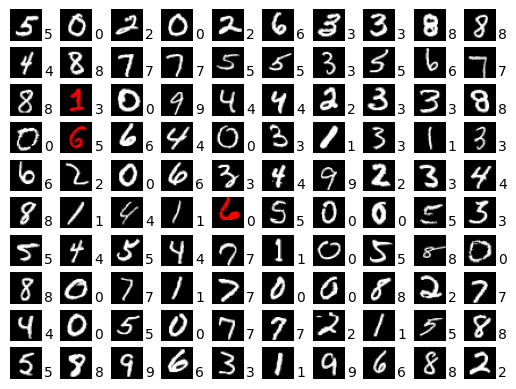

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.129740
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.029450
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.102494
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.123553
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.044705
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.128741
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.066745
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.135255
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.011597
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.038905

Test set: Average loss: 0.0944, Accuracy: 9725/10000 (97.25%)



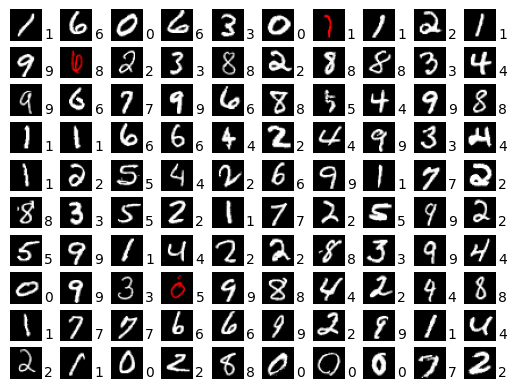

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.020640
Train Epoch: 3 [6400/60000 (11%)]	Loss: 0.084667
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.008734
Train Epoch: 3 [19200/60000 (32%)]	Loss: 0.008924
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.070871
Train Epoch: 3 [32000/60000 (53%)]	Loss: 0.146549
Train Epoch: 3 [38400/60000 (64%)]	Loss: 0.055835
Train Epoch: 3 [44800/60000 (75%)]	Loss: 0.063214
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.004208
Train Epoch: 3 [57600/60000 (96%)]	Loss: 0.007639

Test set: Average loss: 0.0817, Accuracy: 9775/10000 (97.75%)



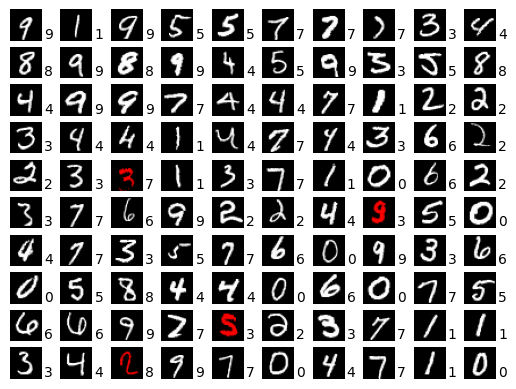

Train Epoch: 4 [0/60000 (0%)]	Loss: 0.030871
Train Epoch: 4 [6400/60000 (11%)]	Loss: 0.015520
Train Epoch: 4 [12800/60000 (21%)]	Loss: 0.098763
Train Epoch: 4 [19200/60000 (32%)]	Loss: 0.012953
Train Epoch: 4 [25600/60000 (43%)]	Loss: 0.015890
Train Epoch: 4 [32000/60000 (53%)]	Loss: 0.003701
Train Epoch: 4 [38400/60000 (64%)]	Loss: 0.003505
Train Epoch: 4 [44800/60000 (75%)]	Loss: 0.007636
Train Epoch: 4 [51200/60000 (85%)]	Loss: 0.007130
Train Epoch: 4 [57600/60000 (96%)]	Loss: 0.011839

Test set: Average loss: 0.0709, Accuracy: 9816/10000 (98.16%)



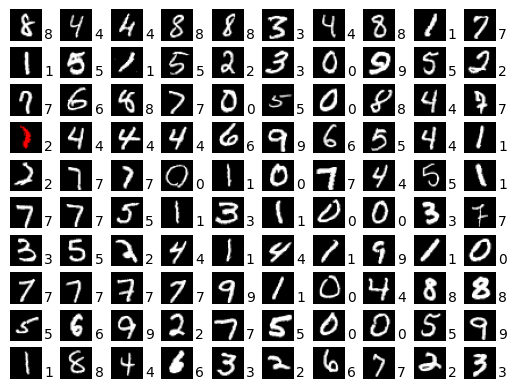

Train Epoch: 5 [0/60000 (0%)]	Loss: 0.019185
Train Epoch: 5 [6400/60000 (11%)]	Loss: 0.012090
Train Epoch: 5 [12800/60000 (21%)]	Loss: 0.009716
Train Epoch: 5 [19200/60000 (32%)]	Loss: 0.075469
Train Epoch: 5 [25600/60000 (43%)]	Loss: 0.008037
Train Epoch: 5 [32000/60000 (53%)]	Loss: 0.000525
Train Epoch: 5 [38400/60000 (64%)]	Loss: 0.000802
Train Epoch: 5 [44800/60000 (75%)]	Loss: 0.004266
Train Epoch: 5 [51200/60000 (85%)]	Loss: 0.084413
Train Epoch: 5 [57600/60000 (96%)]	Loss: 0.000594

Test set: Average loss: 0.0812, Accuracy: 9801/10000 (98.01%)



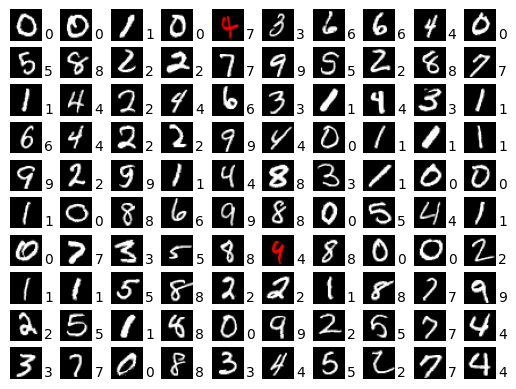

Train Epoch: 6 [0/60000 (0%)]	Loss: 0.029941
Train Epoch: 6 [6400/60000 (11%)]	Loss: 0.032828
Train Epoch: 6 [12800/60000 (21%)]	Loss: 0.074028
Train Epoch: 6 [19200/60000 (32%)]	Loss: 0.047454
Train Epoch: 6 [25600/60000 (43%)]	Loss: 0.002607
Train Epoch: 6 [32000/60000 (53%)]	Loss: 0.039107
Train Epoch: 6 [38400/60000 (64%)]	Loss: 0.001038
Train Epoch: 6 [44800/60000 (75%)]	Loss: 0.138216
Train Epoch: 6 [51200/60000 (85%)]	Loss: 0.002161
Train Epoch: 6 [57600/60000 (96%)]	Loss: 0.006515

Test set: Average loss: 0.0811, Accuracy: 9809/10000 (98.09%)



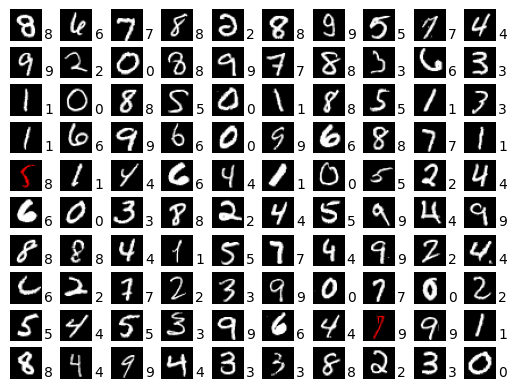

Train Epoch: 7 [0/60000 (0%)]	Loss: 0.000287
Train Epoch: 7 [6400/60000 (11%)]	Loss: 0.013286
Train Epoch: 7 [12800/60000 (21%)]	Loss: 0.007943
Train Epoch: 7 [19200/60000 (32%)]	Loss: 0.086461
Train Epoch: 7 [25600/60000 (43%)]	Loss: 0.000568
Train Epoch: 7 [32000/60000 (53%)]	Loss: 0.002204
Train Epoch: 7 [38400/60000 (64%)]	Loss: 0.041731
Train Epoch: 7 [44800/60000 (75%)]	Loss: 0.006265
Train Epoch: 7 [51200/60000 (85%)]	Loss: 0.002734
Train Epoch: 7 [57600/60000 (96%)]	Loss: 0.003499

Test set: Average loss: 0.0845, Accuracy: 9811/10000 (98.11%)



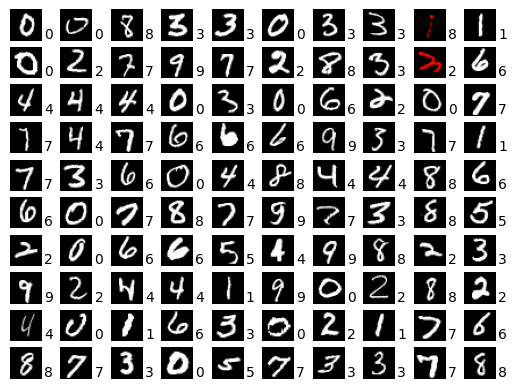

Train Epoch: 8 [0/60000 (0%)]	Loss: 0.002292
Train Epoch: 8 [6400/60000 (11%)]	Loss: 0.000428
Train Epoch: 8 [12800/60000 (21%)]	Loss: 0.000327
Train Epoch: 8 [19200/60000 (32%)]	Loss: 0.118740
Train Epoch: 8 [25600/60000 (43%)]	Loss: 0.005977
Train Epoch: 8 [32000/60000 (53%)]	Loss: 0.000476
Train Epoch: 8 [38400/60000 (64%)]	Loss: 0.003668
Train Epoch: 8 [44800/60000 (75%)]	Loss: 0.002074
Train Epoch: 8 [51200/60000 (85%)]	Loss: 0.001118
Train Epoch: 8 [57600/60000 (96%)]	Loss: 0.004214

Test set: Average loss: 0.0839, Accuracy: 9824/10000 (98.24%)



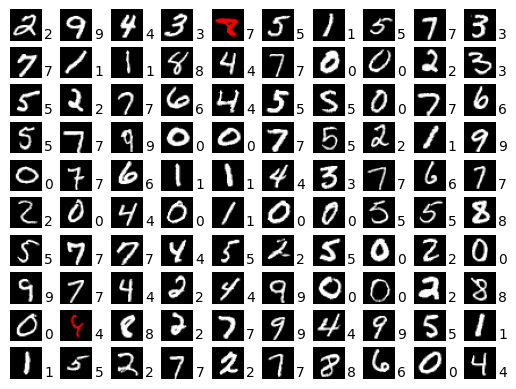

Train Epoch: 9 [0/60000 (0%)]	Loss: 0.001543
Train Epoch: 9 [6400/60000 (11%)]	Loss: 0.003867
Train Epoch: 9 [12800/60000 (21%)]	Loss: 0.000154
Train Epoch: 9 [19200/60000 (32%)]	Loss: 0.000391
Train Epoch: 9 [25600/60000 (43%)]	Loss: 0.001105
Train Epoch: 9 [32000/60000 (53%)]	Loss: 0.003977
Train Epoch: 9 [38400/60000 (64%)]	Loss: 0.000641
Train Epoch: 9 [44800/60000 (75%)]	Loss: 0.032193
Train Epoch: 9 [51200/60000 (85%)]	Loss: 0.001967
Train Epoch: 9 [57600/60000 (96%)]	Loss: 0.066804

Test set: Average loss: 0.0882, Accuracy: 9815/10000 (98.15%)



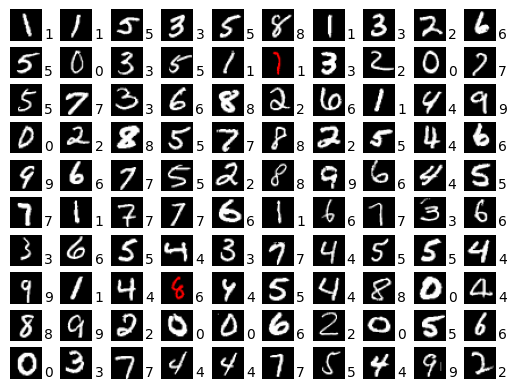

Train Epoch: 10 [0/60000 (0%)]	Loss: 0.001398
Train Epoch: 10 [6400/60000 (11%)]	Loss: 0.002152
Train Epoch: 10 [12800/60000 (21%)]	Loss: 0.007260
Train Epoch: 10 [19200/60000 (32%)]	Loss: 0.002259
Train Epoch: 10 [25600/60000 (43%)]	Loss: 0.000337
Train Epoch: 10 [32000/60000 (53%)]	Loss: 0.006884
Train Epoch: 10 [38400/60000 (64%)]	Loss: 0.001930
Train Epoch: 10 [44800/60000 (75%)]	Loss: 0.074152
Train Epoch: 10 [51200/60000 (85%)]	Loss: 0.208736
Train Epoch: 10 [57600/60000 (96%)]	Loss: 0.000923

Test set: Average loss: 0.0887, Accuracy: 9816/10000 (98.16%)



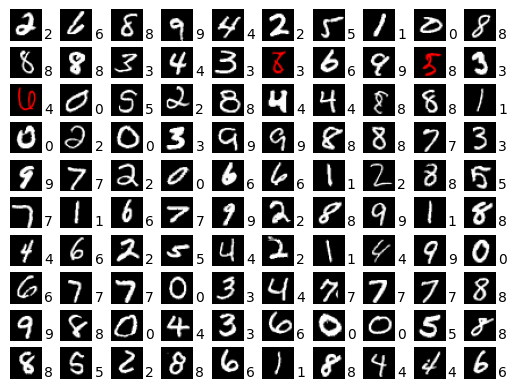

In [10]:
# hyper parameters
batch_size = 64
test_batch_size = 1000
epochs = 10
lr = 1.0
gamma = 0.7
log_interval = 100

# use GPU if available
use_cuda = torch.cuda.is_available()
kwargs = {'num_workers': 1, 'pin_memory': True} if use_cuda else {}

# initialize data loaders
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=True, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])), batch_size=batch_size, shuffle=True, **kwargs)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, 
    transform=transforms.Compose([
        transforms.ToTensor(), 
        transforms.Normalize((0.1307,), (0.3081,))
    ])),
    batch_size=test_batch_size, shuffle=True, **kwargs)

model = FCNet2()
if use_cuda:
    model = model.cuda()

# initialize optimizer and scheduler
optimizer = optim.Adadelta(model.parameters(), lr=lr)
scheduler = StepLR(optimizer, step_size=1, gamma=gamma)

for epoch in range(1, epochs + 1):
    # train one epoch
    train(model, use_cuda, train_loader, optimizer, epoch, log_interval)
    
    # run on test dataset
    validate(model, use_cuda, test_loader)
    scheduler.step()
    
    
    torch.save(model.state_dict(), "models/mnist/checkpoint.pt")

Model: FCNet1, Epoch: 1
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.254353


/Users/michaelale/Desktop/Heidelberg University/Summer 2026/Computer Vision/Tutorial/3dcv-students/venv/lib/python3.10/site-packages/torch/nn/functional.py:1960: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.302660
Train Epoch: 1 [12800/60000 (21%)]	Loss: 2.301798
Train Epoch: 1 [19200/60000 (32%)]	Loss: 2.309537
Train Epoch: 1 [25600/60000 (43%)]	Loss: 2.312061
Train Epoch: 1 [32000/60000 (53%)]	Loss: 2.287841
Train Epoch: 1 [38400/60000 (64%)]	Loss: 2.297909
Train Epoch: 1 [44800/60000 (75%)]	Loss: 2.232433
Train Epoch: 1 [51200/60000 (85%)]	Loss: 1.899472
Train Epoch: 1 [57600/60000 (96%)]	Loss: 1.711917

Test set: Average loss: 1.3907, Accuracy: 4896/10000 (48.96%)



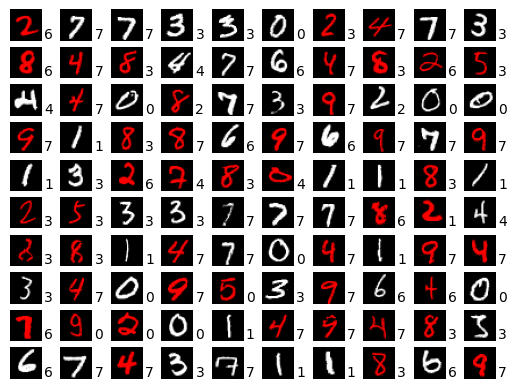

Model: FCNet1, Epoch: 2
Train Epoch: 2 [0/60000 (0%)]	Loss: 1.454557
Train Epoch: 2 [6400/60000 (11%)]	Loss: 1.145960
Train Epoch: 2 [12800/60000 (21%)]	Loss: 1.060497
Train Epoch: 2 [19200/60000 (32%)]	Loss: 1.108150
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.775417
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.710032
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.720089
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.380851
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.505811
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.598669

Test set: Average loss: 0.4798, Accuracy: 8948/10000 (89.48%)



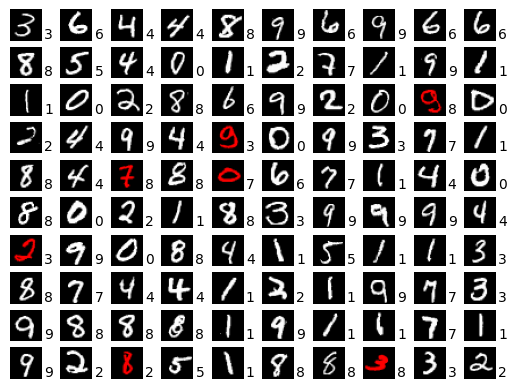

Model: FCNet2, Epoch: 1
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.289514
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.449410
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.164487
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.211046
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.166322
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.140512
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.128608
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.225186
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.258740
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.102674

Test set: Average loss: 0.1332, Accuracy: 9625/10000 (96.25%)



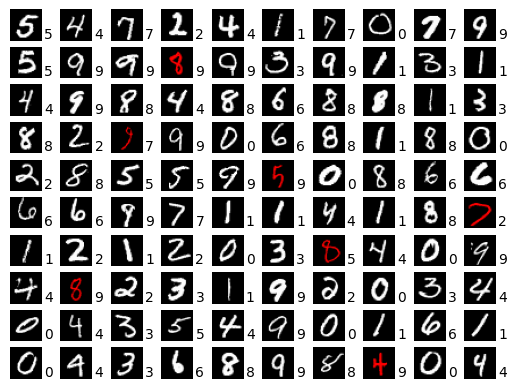

Model: FCNet2, Epoch: 2
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.090797
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.044878
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.081275
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.128844
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.032438
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.188530
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.043824
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.111745
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.057104
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.025024

Test set: Average loss: 0.0926, Accuracy: 9749/10000 (97.49%)



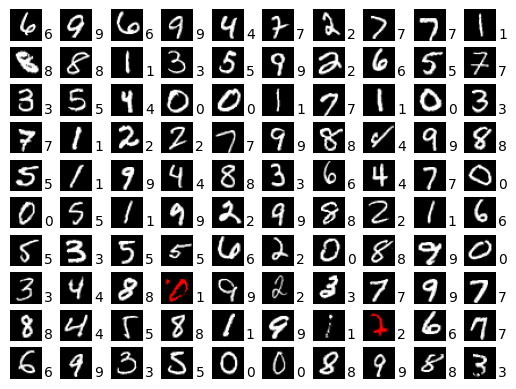

Model: FCNet3, Epoch: 1
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.295310
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.183496
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.128511
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.249116
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.178012
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.110655
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.130276
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.150541
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.133595
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.121101

Test set: Average loss: 0.1190, Accuracy: 9653/10000 (96.53%)



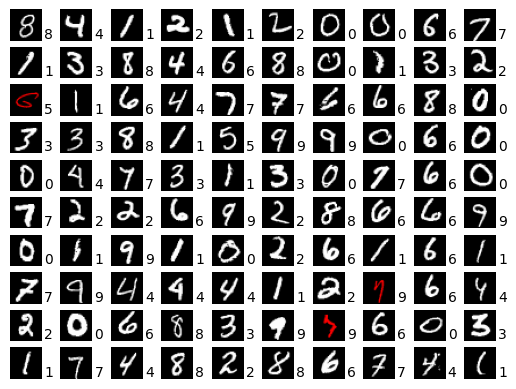

Model: FCNet3, Epoch: 2
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.138023
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.034152
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.026214
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.034236
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.015236
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.230711
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.044863
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.010293
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.093846
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.081511

Test set: Average loss: 0.0819, Accuracy: 9765/10000 (97.65%)



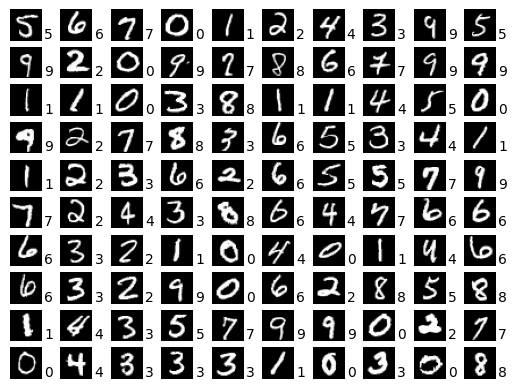

Model: ConvNet1, Epoch: 1
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.298579
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.142560
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.306245
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.062997
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.096488
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.009687
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.007198
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.077955
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.051561
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.036500

Test set: Average loss: 0.0403, Accuracy: 9859/10000 (98.59%)



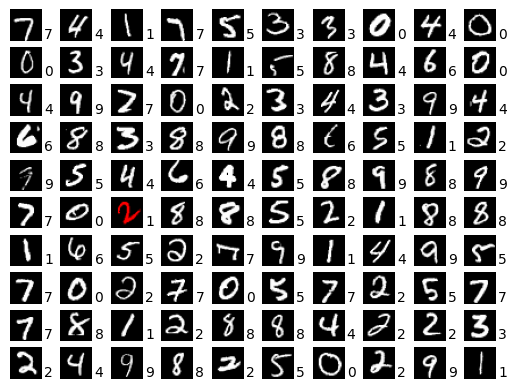

Model: ConvNet1, Epoch: 2
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.004145
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.014163
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.020417
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.000098
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.061802
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.005382
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.047369
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.016958
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.017636
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.039100

Test set: Average loss: 0.0346, Accuracy: 9889/10000 (98.89%)



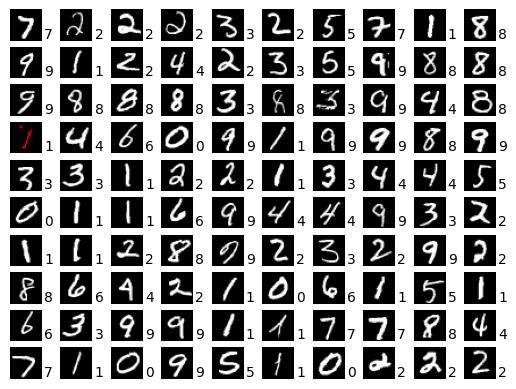

Model: ConvNet2, Epoch: 1
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.377495
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.178165
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.113930
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.073164
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.137688
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.028120
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.035744
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.067095
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.017456
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.044733

Test set: Average loss: 0.0525, Accuracy: 9837/10000 (98.37%)



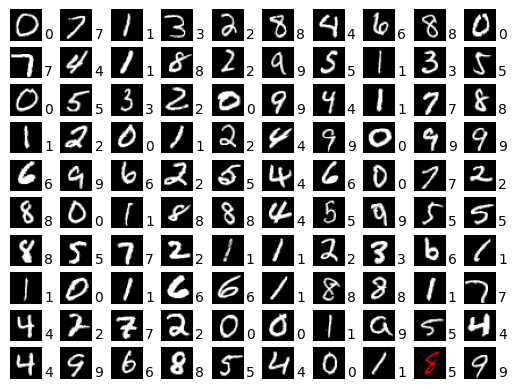

Model: ConvNet2, Epoch: 2
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.003851
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.045627
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.014455
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.008939
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.041169
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.004058
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.003348
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.021439
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.004219
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.036245

Test set: Average loss: 0.0289, Accuracy: 9904/10000 (99.04%)



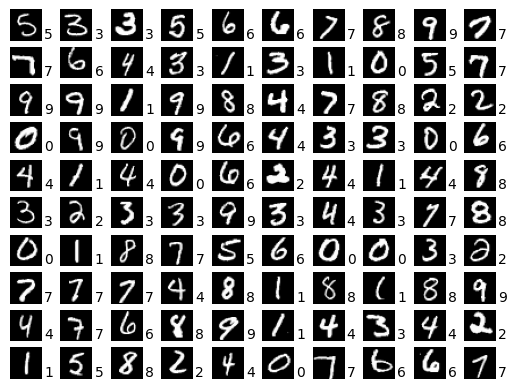

Model: ConvNet3, Epoch: 1
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.447541
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.140030
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.027473
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.017357
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.030374
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.008887
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.027135
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.043048
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.158354
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.015803

Test set: Average loss: 0.0430, Accuracy: 9866/10000 (98.66%)



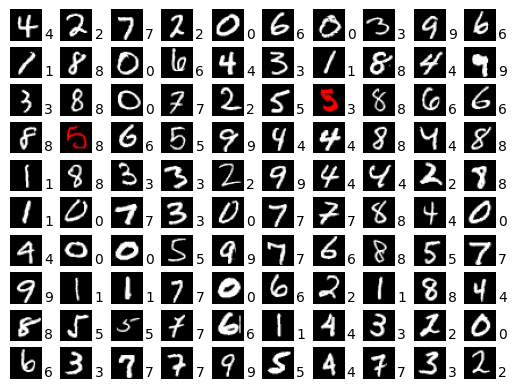

Model: ConvNet3, Epoch: 2
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.022768
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.027945
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.027850
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.073237
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.000984
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.013211
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.073488
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.043099
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.009943
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.003182

Test set: Average loss: 0.0343, Accuracy: 9891/10000 (98.91%)



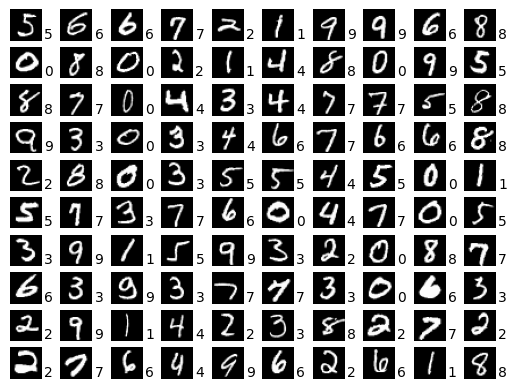

In [11]:
Models = [FCNet1(), FCNet2(), FCNet3(), ConvNet1(), ConvNet2(), ConvNet3()]

epochs = 2

for model in Models:
    
    optimizer = optim.Adadelta(model.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=1, gamma=gamma)

    for epoch in range(1, epochs + 1):
        # train one epoch
        print ("Model: {}, Epoch: {}".format(model.__class__.__name__, epoch))
        train(model, use_cuda, train_loader, optimizer, epoch, log_interval)
        
        # run on test dataset
        validate(model, use_cuda, test_loader)
        scheduler.step()

True
